In [94]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [95]:
metrics_path = Path(
    "../data/processed/final_brand_metrics.parquet"
)

metrics = pd.read_parquet(metrics_path)

print("Dataset shape:", metrics.shape)
metrics.head()

Dataset shape: (67, 14)


,brand_name,price_tier,listing_count,resale_strength,median_price,relative_price_spread,condition_resilience,qualifying_shoe_types,resale_strength_score,consistency_score,resilience_score,overall_score,tier_rank,evidence_level
0,ALDO,Mid-Market,363,0.920000,21.0,0.666667,0.572581,2.0,50.877193,36.842105,39.393939,42.371079,25,Moderate
1,ASICS,Mid-Market,335,0.850000,26.0,0.692308,0.500000,1.0,35.087719,28.947368,18.181818,27.405635,29,Limited
2,Adidas,Premium,1965,0.975610,51.0,1.098039,0.500000,3.0,41.379310,27.586207,8.695652,25.887056,22,Moderate
3,American Eagle,Value,500,1.000000,14.0,0.642857,0.772727,3.0,45.000000,15.000000,63.636364,41.212121,9,Moderate
4,Ariat,Premium,207,0.842857,51.0,0.529412,0.676056,1.0,24.137931,86.206897,43.478261,51.274363,14,Limited


In [96]:
tier_name_map = {
    "Premium": "High Resale",
    "Mid-Market": "Mid Resale",
    "Value": "Low Resale"
}

metrics["resale_tier"] = (
    metrics["price_tier"]
    .map(tier_name_map)
)

metrics[["price_tier", "resale_tier"]].drop_duplicates()

,price_tier,resale_tier
0,Mid-Market,Mid Resale
2,Premium,High Resale
3,Value,Low Resale


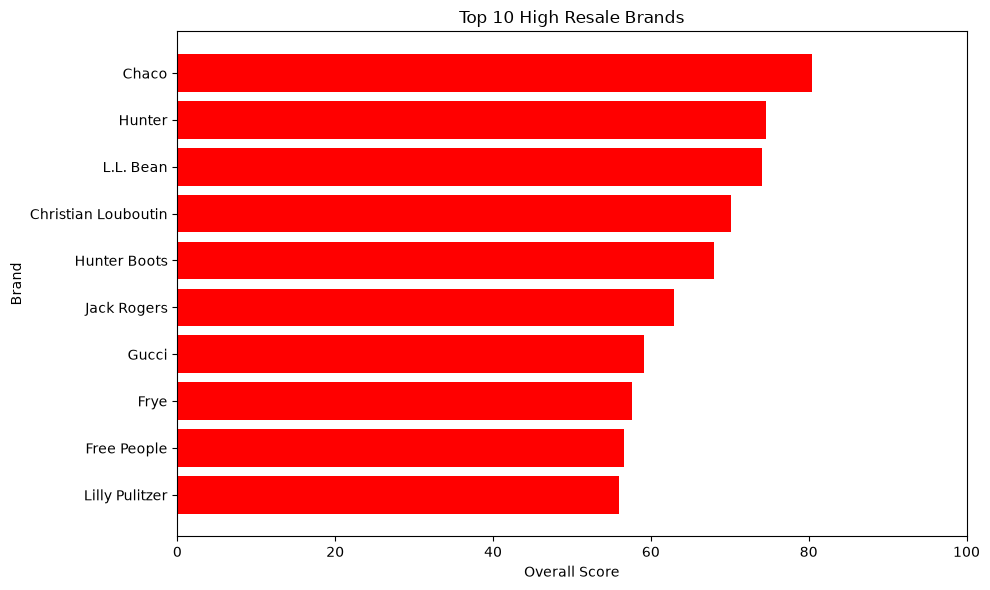

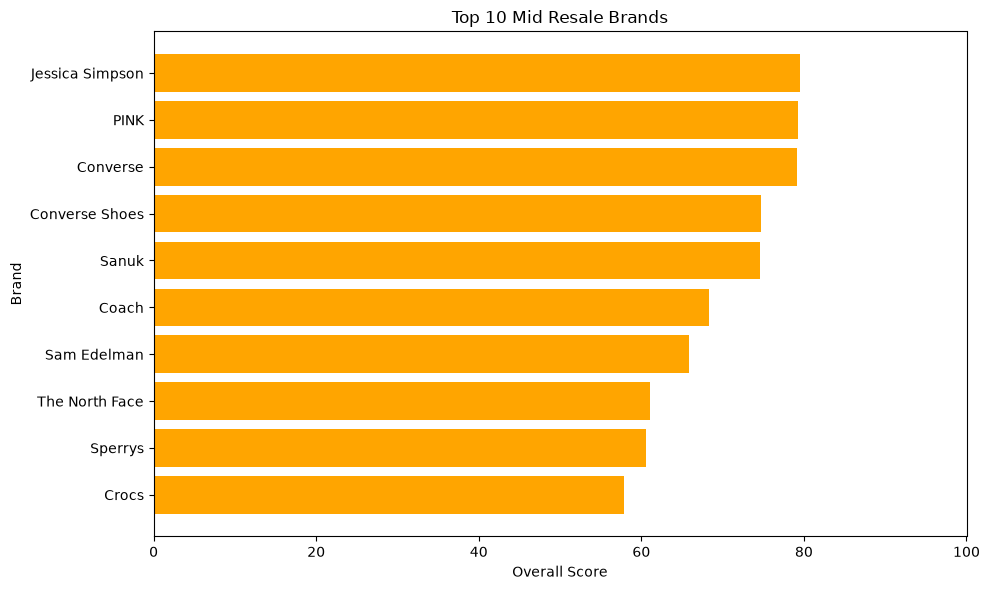

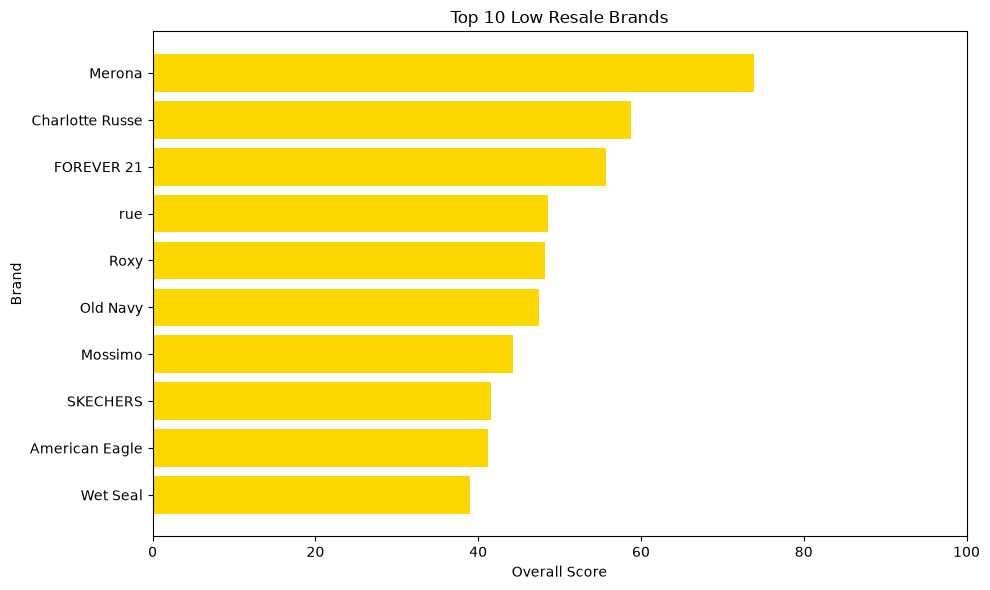

In [97]:
tier_colors = {
    "High Resale": "red",
    "Mid Resale": "orange",
    "Low Resale": "gold"
}

tier_filenames = {
    "High Resale": "top_high_resale_brands.png",
    "Mid Resale": "top_mid_resale_brands.png",
    "Low Resale": "top_low_resale_brands.png"
}

for tier in ["High Resale", "Mid Resale", "Low Resale"]:
    top_brands = (
        metrics[metrics["resale_tier"] == tier]
        .sort_values("overall_score", ascending=False)
        .head(10)
        .sort_values("overall_score")
    )

    plt.figure(figsize=(10, 6))

    plt.barh(
        top_brands["brand_name"],
        top_brands["overall_score"],
        color=tier_colors[tier]
    )

    plt.xlabel("Overall Score")
    plt.ylabel("Brand")
    plt.title(f"Top 10 {tier} Brands")
    plt.xlim(0, 100)

    plt.tight_layout()

    plt.savefig(
        f"../outputs/charts/{tier_filenames[tier]}",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

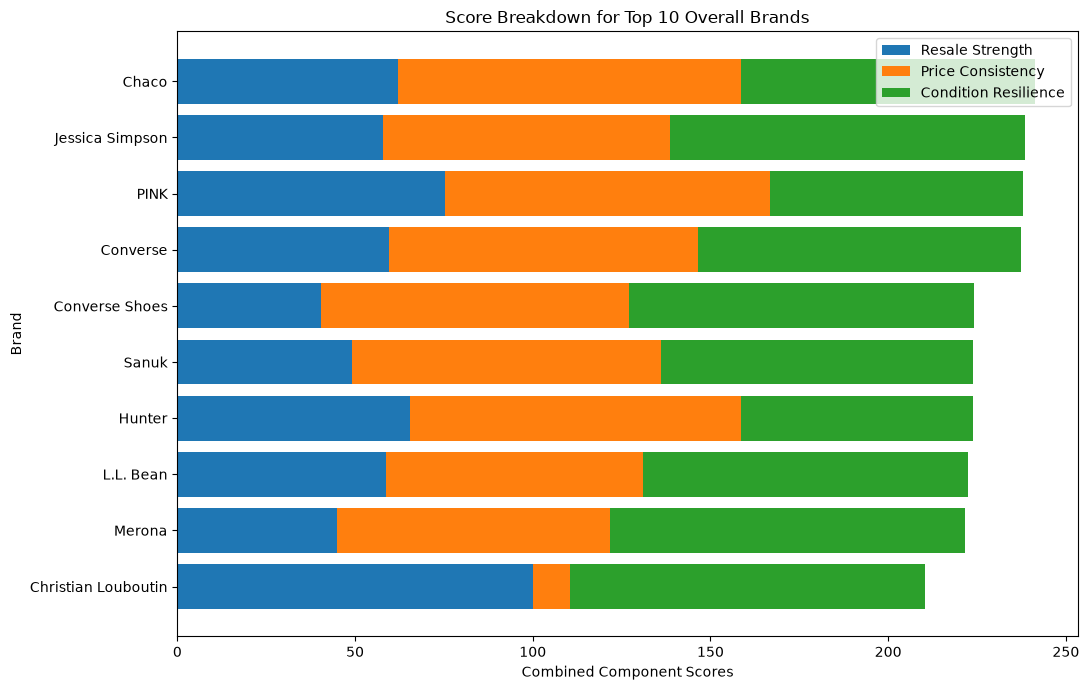

In [98]:
top_overall = (
    metrics
    .sort_values("overall_score", ascending=False)
    .head(10)
    .copy()
)

top_overall = top_overall.sort_values("overall_score")

plt.figure(figsize=(11, 7))

plt.barh(
    top_overall["brand_name"],
    top_overall["resale_strength_score"],
    label="Resale Strength"
)

plt.barh(
    top_overall["brand_name"],
    top_overall["consistency_score"],
    left=top_overall["resale_strength_score"],
    label="Price Consistency"
)

plt.barh(
    top_overall["brand_name"],
    top_overall["resilience_score"],
    left=(
        top_overall["resale_strength_score"]
        + top_overall["consistency_score"]
    ),
    label="Condition Resilience"
)

plt.xlabel("Combined Component Scores")
plt.ylabel("Brand")
plt.title("Score Breakdown for Top 10 Overall Brands")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../outputs/charts/metric_breakdown_top10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

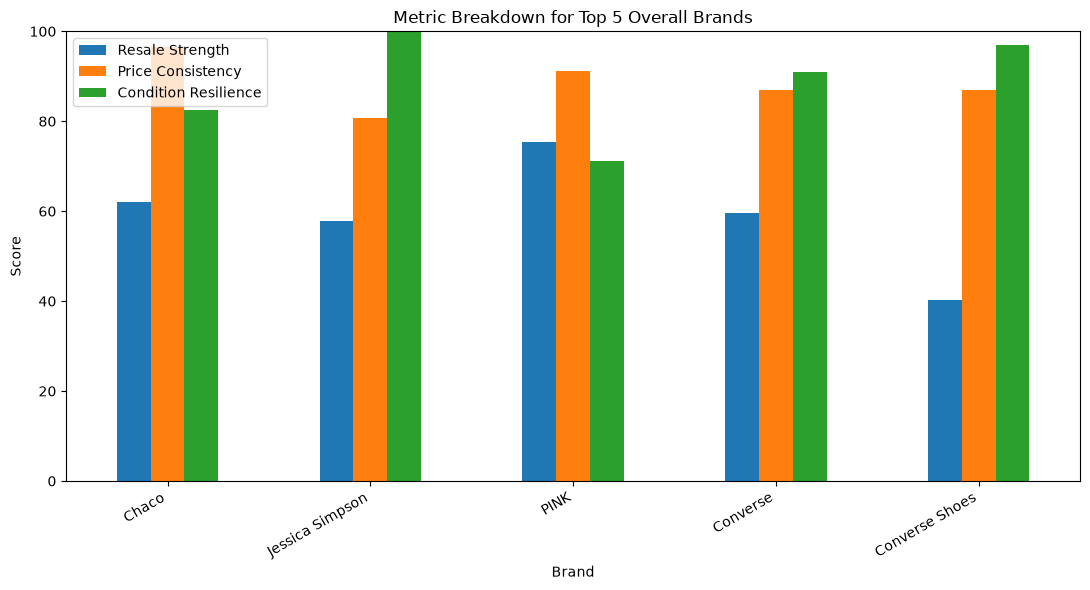

In [99]:
top_five = (
    metrics
    .sort_values("overall_score", ascending=False)
    .head(5)
    .copy()
)

chart_data = top_five.set_index("brand_name")[
    [
        "resale_strength_score",
        "consistency_score",
        "resilience_score"
    ]
]

chart_data.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.xlabel("Brand")
plt.ylabel("Score")
plt.title("Metric Breakdown for Top 5 Overall Brands")
plt.ylim(0, 100)
plt.xticks(rotation=30, ha="right")

plt.legend(
    [
        "Resale Strength",
        "Price Consistency",
        "Condition Resilience"
    ]
)

plt.tight_layout()

plt.savefig(
    "../outputs/charts/metric_breakdown_top5_grouped.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

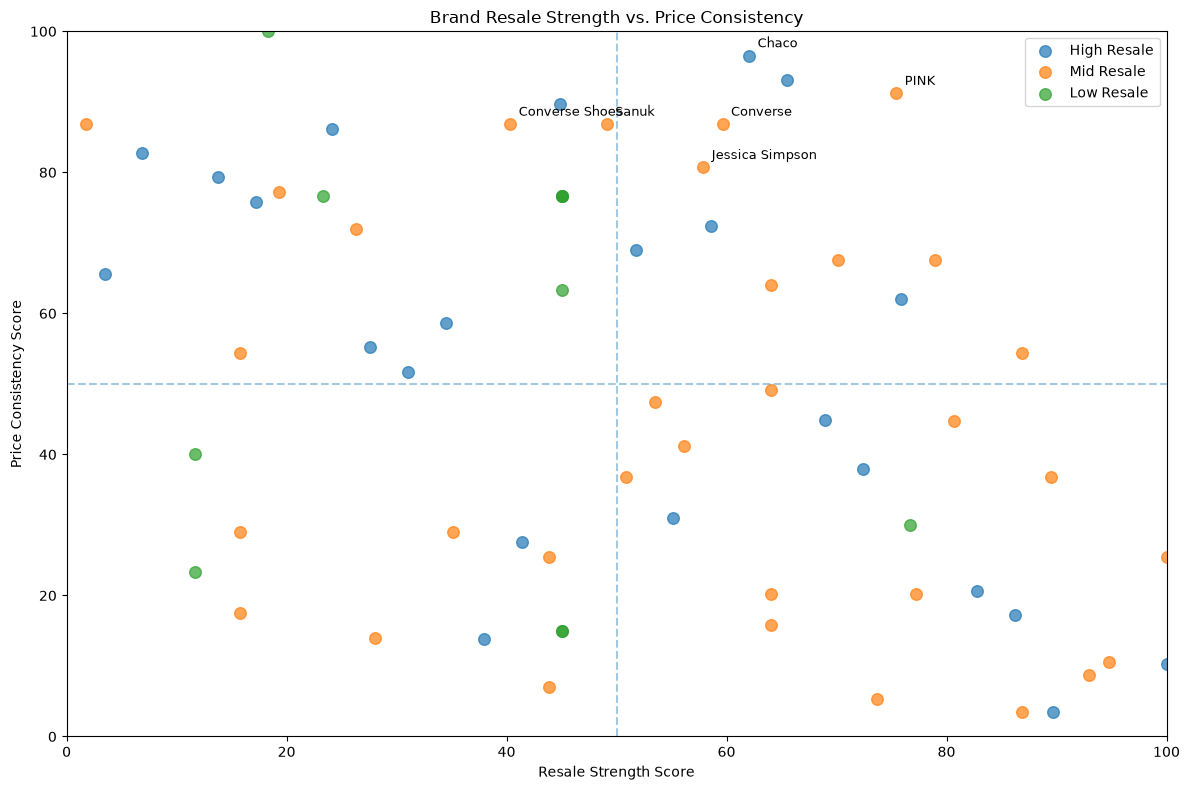

In [100]:
plt.figure(figsize=(12, 8))

for tier in ["High Resale", "Mid Resale", "Low Resale"]:
    tier_data = metrics[metrics["resale_tier"] == tier]

    plt.scatter(
        tier_data["resale_strength_score"],
        tier_data["consistency_score"],
        label=tier,
        alpha=0.7,
        s=70
    )

notable_brands = (
    metrics
    .sort_values("overall_score", ascending=False)
    .head(6)
)

for _, row in notable_brands.iterrows():
    plt.annotate(
        row["brand_name"],
        (
            row["resale_strength_score"],
            row["consistency_score"]
        ),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )

plt.axvline(50, linestyle="--", alpha=0.4)
plt.axhline(50, linestyle="--", alpha=0.4)

plt.xlabel("Resale Strength Score")
plt.ylabel("Price Consistency Score")
plt.title("Brand Resale Strength vs. Price Consistency")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.legend()

plt.tight_layout()

plt.savefig(
    "../outputs/charts/strength_vs_consistency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

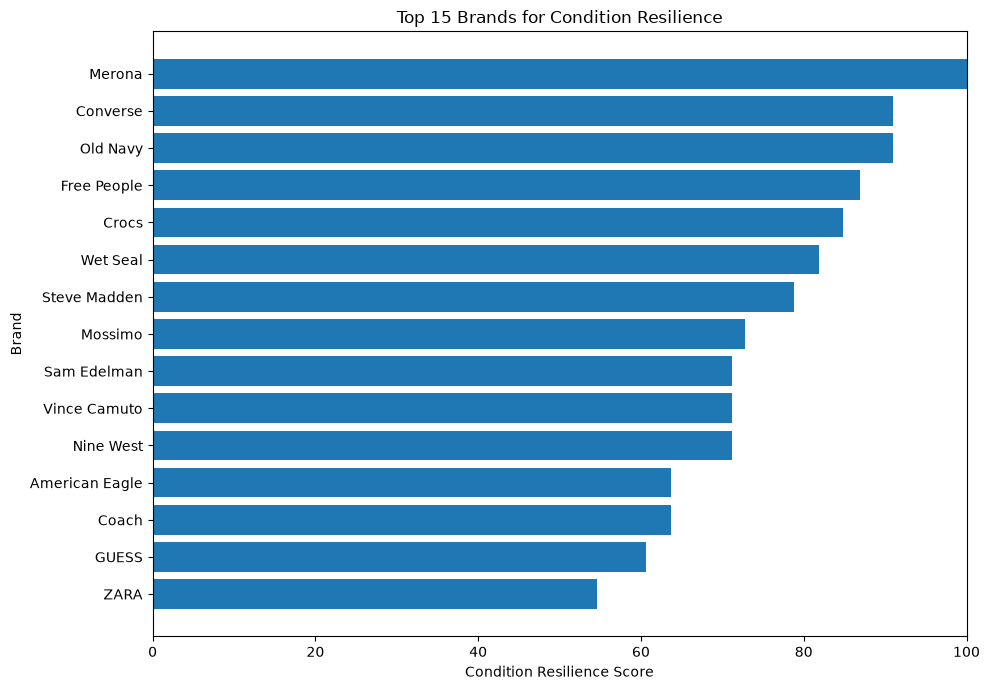

In [101]:
plt.tight_layout()

plt.savefig(
    "../outputs/charts/top_condition_resilience.png",
    dpi=300,
    bbox_inches="tight"
)
reliable_resilience = metrics[
    metrics["evidence_level"].isin(["Moderate", "Strong"])
].copy()

top_resilient = (
    reliable_resilience
    .sort_values("resilience_score", ascending=False)
    .head(15)
    .sort_values("resilience_score")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_resilient["brand_name"],
    top_resilient["resilience_score"]
)

plt.xlabel("Condition Resilience Score")
plt.ylabel("Brand")
plt.title("Top 15 Brands for Condition Resilience")
plt.xlim(0, 100)

plt.tight_layout()
plt.show()

In [102]:
plt.savefig(
    "../outputs/charts/top_tier_winners.png",
    dpi=300,
    bbox_inches="tight"
)
tier_winners = (
    metrics
    .sort_values("overall_score", ascending=False)
    .groupby("resale_tier", as_index=False)
    .first()
)

tier_winners[
    [
        "resale_tier",
        "brand_name",
        "overall_score",
        "resale_strength_score",
        "consistency_score",
        "resilience_score",
        "evidence_level"
    ]
]

,resale_tier,brand_name,overall_score,resale_strength_score,consistency_score,resilience_score,evidence_level
0,High Resale,Chaco,80.409795,62.068966,96.551724,82.608696,Limited
1,Low Resale,Merona,73.888889,45.000000,76.666667,100.000000,Moderate
2,Mid Resale,Jessica Simpson,79.532164,57.894737,80.701754,100.000000,Limited


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

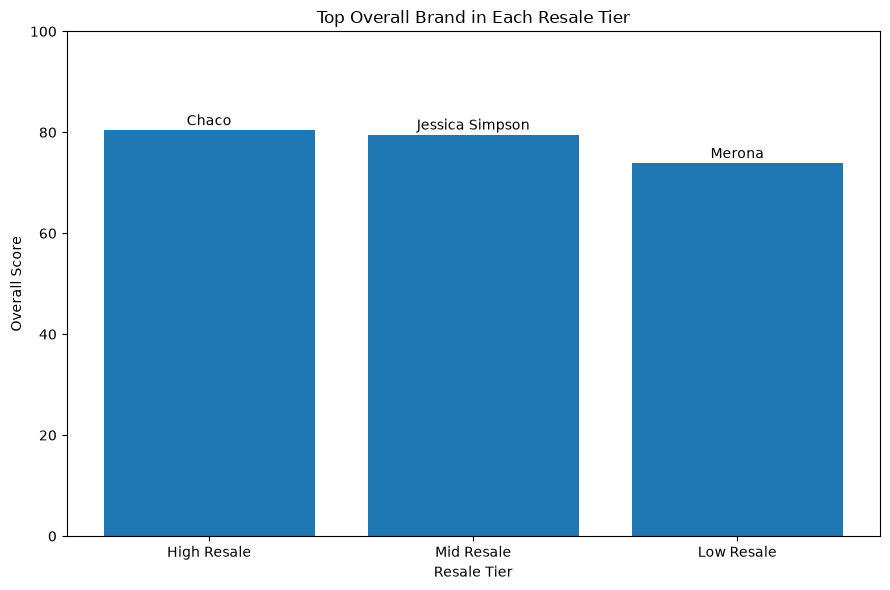

In [103]:
plt.savefig(
    "../outputs/charts/top_overall_brand_in_each_tier.png",
    dpi=300,
    bbox_inches="tight"
)
tier_order = [
    "High Resale",
    "Mid Resale",
    "Low Resale"
]

tier_winners["resale_tier"] = pd.Categorical(
    tier_winners["resale_tier"],
    categories=tier_order,
    ordered=True
)

tier_winners = tier_winners.sort_values("resale_tier")
plt.figure(figsize=(9, 6))

plt.bar(
    tier_winners["resale_tier"],
    tier_winners["overall_score"]
)

plt.xlabel("Resale Tier")
plt.ylabel("Overall Score")
plt.title("Top Overall Brand in Each Resale Tier")
plt.ylim(0, 100)

for index, row in tier_winners.reset_index(drop=True).iterrows():
    plt.text(
        index,
        row["overall_score"] + 1,
        row["brand_name"],
        ha="center"
    )

plt.tight_layout()
plt.show()